In [9]:
import pandas as pd
import numpy as np


In [10]:
all_data = pd.read_csv('/content/drive/MyDrive/Копия forest_dataset.csv')
all_data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [11]:
all_data.shape

(10000, 55)

In [12]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(feature_matrix, labels, test_size=0.2, random_state=42)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
clf.fit(train_feature_matrix, train_labels);

In [16]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_neighbors': np.arange(1, 11),
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'euclidean'],
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels);


In [17]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}

In [18]:
optimal_clf = KNeighborsClassifier(n_neighbors=4, weights='distance', metric='manhattan')
optimal_clf.fit(train_feature_matrix, train_labels)
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

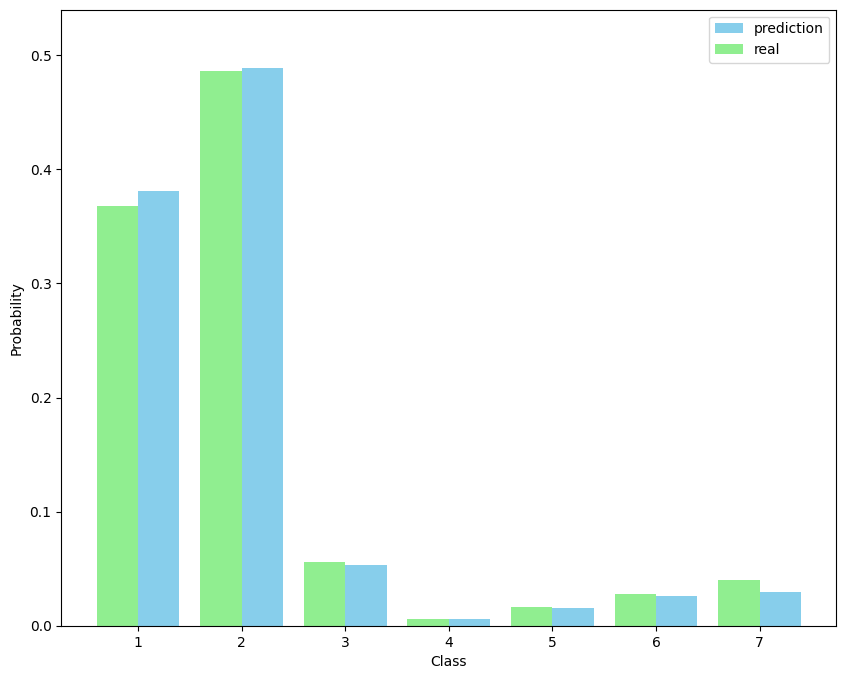

In [23]:

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels),freq))

pred_freq = pred_prob.mean(axis=0)
plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction', color='skyblue')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real', color='lightgreen')
plt.ylim(0, 0.54)
plt.xlabel('Class')
plt.ylabel('Probability')
plt.legend()
plt.show()

Заключение

In [20]:
accuracy_knn = accuracy_score(test_labels, optimal_clf.predict(test_feature_matrix))
accuracy_knn

0.7845

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
train_feature_matrix_scaled = scaler.fit_transform(train_feature_matrix)
test_feature_matrix_scaled = scaler.transform(test_feature_matrix)

logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(train_feature_matrix_scaled, train_labels)

score_log_regr = logistic_regression.score(test_feature_matrix_scaled, test_labels)
score_log_regr

0.718

Преимущества метода kNN заключаются в его простоте и понятном принципе работы. Алгоритм подходит как для задач классификации, так и для регрессии. Процесс обучения занимает минимальное время, поскольку модель фактически не строит сложных зависимостей, а сохраняет обучающие данные для дальнейшего использования.

К недостаткам kNN можно отнести высокие затраты по времени при выполнении предсказаний. Для определения класса нового объекта алгоритму требуется вычислить расстояния до всех элементов обучающей выборки, после чего выбрать ближайших соседей. Кроме того, метод достаточно чувствителен к выбросам и шумовым данным. Подбор оптимального значения параметра k обычно осуществляется экспериментально, например с применением кросс-валидации.

Нельзя утверждать, что одна из моделей всегда превосходит другую. Выбор между логистической регрессией и kNN определяется особенностями конкретной задачи и структурой данных. Алгоритм kNN чаще показывает хорошие результаты на небольших выборках и при наличии нелинейных зависимостей. Логистическая регрессия, в свою очередь, более эффективна в случаях, когда данные можно разделить линейно и требуется быстрое получение предсказаний.


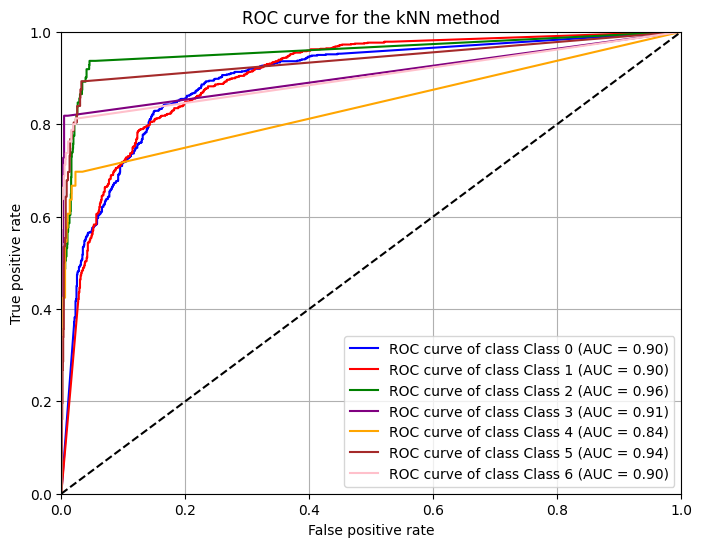

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(labels))
test_labels_bin = label_binarize(test_labels, classes=np.unique(labels))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label='ROC curve of class {0} (AUC = {1:.2f})'.format(f'Class {i}', roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve for the kNN method')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()